# 流式输出
- stream/astream，两者只是在迭代时有差异，astream迭代时需要添加async
- 且stream支持多版本(v1和v2)，默认v1
    - v1如果stream_mode只了一个模式字符串，只返回具体的内容，如果传的是模式列表，则会返回元组(mode, data), 元组中mode以区分不同模式的输出
    - v2在v1的基础上封装了，固定返回一个StreamPart，固定包含type\ns\data三个字段
- stream_mode
    - values: 每个超步执行后的的全量状态（并行节点一次流式输出）
    - updates: 节点执行产生的状态更新（增量）(是节点执行完成后，不是超步，所以并行节点会分多次流式输出)
    - messages: 返回messages状态字段的增量更新（在调用大模型时，会输出AIMessageChunk（大模型的流式输出））
    - checkpoints: checkpoints更新事件（需检查点存储器）
    - tasks: 返回每个超步的tasks
    - debug: checkpoints+tasks的统一封装，附加超步变化，时间戳等
    - custom: 自定义流失返回。工具可以通过ToolRuntime获取stream_writer, 节点可以通过Runtime获取stream_writer对内容流式写出。也可以通过`get_stream_writer()`获取

- 底层机制（langgraph 1.1.2）
    - stream()调用`SyncQueue()`创建FIFO的队列，接收运行时写入的chunk
    - 根据stream_mode在不同时机写入chunk
    - 在图执行过程中：（PregelRunnber?）runner.tick()交换控制权时，会调用`__output()`,从队列中取出chunk，yield给调用方；
    - 还有在超步循环结束后收尾会调用`__output()`从队列取出chunk，yield给调用方

## Stream_mode演示：values

In [4]:
from typing import TypedDict
from langgraph.graph import StateGraph, START, END

class OverAllState(TypedDict):
    initial_state: str
    node_a_output: str
    node_b_output: str
    node_c_output: str

def node_a(state: OverAllState) -> OverAllState:
    return {
        "node_a_output": "节点A的输出"
    }

def node_b(state: OverAllState) -> OverAllState:
    return {
        "node_b_output": "节点B的输出"
    }

def node_c(state: OverAllState) -> OverAllState:
    return {
        "node_c_output": "节点C的输出"
    }

builder = StateGraph(state_schema=OverAllState)
builder.add_node("node_a", node_a)
builder.add_node("node_b", node_b)
builder.add_node("node_c", node_c)
builder.add_edge(START, "node_a")
builder.add_edge("node_a", "node_b")
builder.add_edge("node_a", "node_c")
builder.add_edge("node_b", END)
builder.add_edge("node_c", END)

graph = builder.compile()
for chunk in graph.stream(
    {"initial_state": "初始状态"},
    stream_mode=["values"],
):
    print(chunk)

('values', {'initial_state': '初始状态'})
('values', {'initial_state': '初始状态', 'node_a_output': '节点A的输出'})
('values', {'initial_state': '初始状态', 'node_a_output': '节点A的输出', 'node_b_output': '节点B的输出', 'node_c_output': '节点C的输出'})


## Stream_mode演示：updates

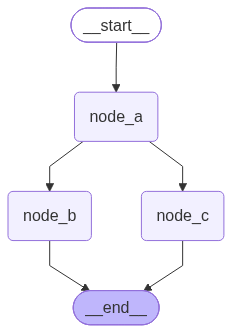

('updates', {'node_a': {'node_a_output': '节点A的输出'}})
('updates', {'node_b': {'node_b_output': '节点B的输出'}})
('updates', {'node_c': {'node_c_output': '节点C的输出'}})


In [3]:
from IPython.core.display import Image, display_png
from typing import TypedDict
from langgraph.graph import StateGraph, START, END

class OverAllState(TypedDict):
    initial_state: str
    node_a_output: str
    node_b_output: str
    node_c_output: str

def node_a(state: OverAllState) -> OverAllState:
    return {
        "node_a_output": "节点A的输出"
    }

def node_b(state: OverAllState) -> OverAllState:
    return {
        "node_b_output": "节点B的输出"
    }

def node_c(state: OverAllState) -> OverAllState:
    return {
        "node_c_output": "节点C的输出"
    }

builder = StateGraph(state_schema=OverAllState)
builder.add_node("node_a", node_a)
builder.add_node("node_b", node_b)
builder.add_node("node_c", node_c)
builder.add_edge(START, "node_a")
builder.add_edge("node_a", "node_b")
builder.add_edge("node_a", "node_c")
builder.add_edge("node_b", END)
builder.add_edge("node_c", END)

png = Image(graph.get_graph().draw_mermaid_png())
display_png(png)

graph = builder.compile()
for chunk in graph.stream(
    {"initial_state": "初始状态"},
    stream_mode=["updates"],
):
    print(chunk)


## Stream_mode演示：messages

In [15]:
from langgraph.graph import StateGraph, START, END, MessagesState

from langchain.messages import HumanMessage
from langchain_deepseek import ChatDeepSeek

from common import init_simple_dashscope_model
from rich import print as rprint

model = init_simple_dashscope_model()

def llm_node(state: MessagesState) -> MessagesState:
    messages = state["messages"]
    response = model.invoke(messages)

    return {
        "messages": [response],
    }

builder = StateGraph(state_schema=MessagesState)
builder.add_node("llm_node", llm_node)
builder.add_edge(START, "llm_node")
builder.add_edge("llm_node", END)

graph = builder.compile()

for chunk in graph.stream(
        {
            "messages":[HumanMessage(content="你好!")]
        },
    stream_mode=["values","messages"],
):
    rprint(chunk)


(
    'values',
    {
        'messages': [
            HumanMessage(
                content='你好!',
                additional_kwargs={},
                response_metadata={},
                id='35d3fae5-c065-414e-9580-65b8d236a51a'
            )
        ]
    }
)

(
    'messages',
    (
        AIMessageChunk(
            content='',
            additional_kwargs={},
            response_metadata={'model_provider': 'openai'},
            id='lc_run--019fff35-cfde-7c53-92ca-6962b9da7652',
            tool_calls=[],
            invalid_tool_calls=[],
            tool_call_chunks=[]
        ),
        {
            'langgraph_step': 1,
            'langgraph_node': 'llm_node',
            'langgraph_triggers': ('branch:to:llm_node',),
            'langgraph_path': ('__pregel_pull', 'llm_node'),
            'langgraph_checkpoint_ns': 'llm_node:0c67def5-28ed-8856-5bae-c4ccbc08d7d6',
            'checkpoint_ns': 'llm_node:0c67def5-28ed-8856-5bae-c4ccbc08d7d6',
            'ls_provider': 'openai',
            'ls_model_name': 'qwen3.7-plus',
            'ls_model_type': 'chat',
            'ls_temperature': None
        }
    )
)

(
    'messages',
    (
        AIMessageChunk(
            content='',
            additional_kwargs={},
            response_metadata={'model_provider': 'openai'},
            id='lc_run--019fff35-cfde-7c53-92ca-6962b9da7652',
            tool_calls=[],
            invalid_tool_calls=[],
            tool_call_chunks=[]
        ),
        {
            'langgraph_step': 1,
            'langgraph_node': 'llm_node',
            'langgraph_triggers': ('branch:to:llm_node',),
            'langgraph_path': ('__pregel_pull', 'llm_node'),
            'langgraph_checkpoint_ns': 'llm_node:0c67def5-28ed-8856-5bae-c4ccbc08d7d6',
            'checkpoint_ns': 'llm_node:0c67def5-28ed-8856-5bae-c4ccbc08d7d6',
            'ls_provider': 'openai',
            'ls_model_name': 'qwen3.7-plus',
            'ls_model_type': 'chat',
            'ls_temperature': None
        }
    )
)

(
    'messages',
    (
        AIMessageChunk(
            content='',
            additional_kwargs={},
            response_metadata={'model_provider': 'openai'},
            id='lc_run--019fff35-cfde-7c53-92ca-6962b9da7652',
            tool_calls=[],
            invalid_tool_calls=[],
            tool_call_chunks=[]
        ),
        {
            'langgraph_step': 1,
            'langgraph_node': 'llm_node',
            'langgraph_triggers': ('branch:to:llm_node',),
            'langgraph_path': ('__pregel_pull', 'llm_node'),
            'langgraph_checkpoint_ns': 'llm_node:0c67def5-28ed-8856-5bae-c4ccbc08d7d6',
            'checkpoint_ns': 'llm_node:0c67def5-28ed-8856-5bae-c4ccbc08d7d6',
            'ls_provider': 'openai',
            'ls_model_name': 'qwen3.7-plus',
            'ls_model_type': 'chat',
            'ls_temperature': None
        }
    )
)

(
    'messages',
    (
        AIMessageChunk(
            content='',
            additional_kwargs={},
            response_metadata={'model_provider': 'openai'},
            id='lc_run--019fff35-cfde-7c53-92ca-6962b9da7652',
            tool_calls=[],
            invalid_tool_calls=[],
            tool_call_chunks=[]
        ),
        {
            'langgraph_step': 1,
            'langgraph_node': 'llm_node',
            'langgraph_triggers': ('branch:to:llm_node',),
            'langgraph_path': ('__pregel_pull', 'llm_node'),
            'langgraph_checkpoint_ns': 'llm_node:0c67def5-28ed-8856-5bae-c4ccbc08d7d6',
            'checkpoint_ns': 'llm_node:0c67def5-28ed-8856-5bae-c4ccbc08d7d6',
            'ls_provider': 'openai',
            'ls_model_name': 'qwen3.7-plus',
            'ls_model_type': 'chat',
            'ls_temperature': None
        }
    )
)

...

(
    'messages',
    (
        AIMessageChunk(
            content='吗？',
            additional_kwargs={},
            response_metadata={'model_provider': 'openai'},
            id='lc_run--019fff35-cfde-7c53-92ca-6962b9da7652',
            tool_calls=[],
            invalid_tool_calls=[],
            tool_call_chunks=[]
        ),
        {
            'langgraph_step': 1,
            'langgraph_node': 'llm_node',
            'langgraph_triggers': ('branch:to:llm_node',),
            'langgraph_path': ('__pregel_pull', 'llm_node'),
            'langgraph_checkpoint_ns': 'llm_node:0c67def5-28ed-8856-5bae-c4ccbc08d7d6',
            'checkpoint_ns': 'llm_node:0c67def5-28ed-8856-5bae-c4ccbc08d7d6',
            'ls_provider': 'openai',
            'ls_model_name': 'qwen3.7-plus',
            'ls_model_type': 'chat',
            'ls_temperature': None
        }
    )
)

(
    'messages',
    (
        AIMessageChunk(
            content='',
            additional_kwargs={},
            response_metadata={'finish_reason': 'stop', 'model_name': 'qwen3.7-plus', 'model_provider': 'openai'},
            id='lc_run--019fff35-cfde-7c53-92ca-6962b9da7652',
            tool_calls=[],
            invalid_tool_calls=[],
            tool_call_chunks=[]
        ),
        {
            'langgraph_step': 1,
            'langgraph_node': 'llm_node',
            'langgraph_triggers': ('branch:to:llm_node',),
            'langgraph_path': ('__pregel_pull', 'llm_node'),
            'langgraph_checkpoint_ns': 'llm_node:0c67def5-28ed-8856-5bae-c4ccbc08d7d6',
            'checkpoint_ns': 'llm_node:0c67def5-28ed-8856-5bae-c4ccbc08d7d6',
            'ls_provider': 'openai',
            'ls_model_name': 'qwen3.7-plus',
            'ls_model_type': 'chat',
            'ls_temperature': None
        }
    )
)

(
    'messages',
    (
        AIMessageChunk(
            content='',
            additional_kwargs={},
            response_metadata={},
            id='lc_run--019fff35-cfde-7c53-92ca-6962b9da7652',
            tool_calls=[],
            invalid_tool_calls=[],
            usage_metadata={
                'input_tokens': 12,
                'output_tokens': 126,
                'total_tokens': 138,
                'input_token_details': {'cache_read': 0},
                'output_token_details': {'reasoning': 112}
            },
            tool_call_chunks=[]
        ),
        {
            'langgraph_step': 1,
            'langgraph_node': 'llm_node',
            'langgraph_triggers': ('branch:to:llm_node',),
            'langgraph_path': ('__pregel_pull', 'llm_node'),
            'langgraph_checkpoint_ns': 'llm_node:0c67def5-28ed-8856-5bae-c4ccbc08d7d6',
            'checkpoint_ns': 'llm_node:0c67def5-28ed-8856-5bae-c4ccbc08d7d6',
            'ls_provider': 'openai',
            'ls_model_name': 'qwen3.7-plus',
            'ls_model_type': 'chat',
            'ls_temperature': None
        }
    )
)

(
    'messages',
    (
        AIMessageChunk(
            content='',
            additional_kwargs={},
            response_metadata={},
            id='lc_run--019fff35-cfde-7c53-92ca-6962b9da7652',
            tool_calls=[],
            invalid_tool_calls=[],
            tool_call_chunks=[],
            chunk_position='last'
        ),
        {
            'langgraph_step': 1,
            'langgraph_node': 'llm_node',
            'langgraph_triggers': ('branch:to:llm_node',),
            'langgraph_path': ('__pregel_pull', 'llm_node'),
            'langgraph_checkpoint_ns': 'llm_node:0c67def5-28ed-8856-5bae-c4ccbc08d7d6',
            'checkpoint_ns': 'llm_node:0c67def5-28ed-8856-5bae-c4ccbc08d7d6',
            'ls_provider': 'openai',
            'ls_model_name': 'qwen3.7-plus',
            'ls_model_type': 'chat',
            'ls_temperature': None
        }
    )
)

(
    'values',
    {
        'messages': [
            HumanMessage(
                content='你好!',
                additional_kwargs={},
                response_metadata={},
                id='35d3fae5-c065-414e-9580-65b8d236a51a'
            ),
            AIMessage(
                content='你好！请问有什么我可以帮您的吗？',
                additional_kwargs={},
                response_metadata={
                    'finish_reason': 'stop',
                    'model_name': 'qwen3.7-plus',
                    'model_provider': 'openai'
                },
                id='lc_run--019fff35-cfde-7c53-92ca-6962b9da7652',
                tool_calls=[],
                invalid_tool_calls=[],
                usage_metadata={
                    'input_tokens': 12,
                    'output_tokens': 126,
                    'total_tokens': 138,
                    'input_token_details': {'cache_read': 0},
                    'output_token_details': {'reasoning': 112}
                }
            )
        ]
    }
)

## Stream_mode演示：checkpoints

In [16]:
from typing import TypedDict
from langgraph.graph import StateGraph, START, END
from langgraph.checkpoint.memory import InMemorySaver

from langgraph.types import interrupt, Command
from rich import print as rprint

class OverAllState(TypedDict):
    initial_state: str
    parallel_node_a_1: str
    parallel_node_a_2: str
    node_b_output: str

def parallel_node_a_1(state: OverAllState) -> OverAllState:
    return {
        "parallel_node_a_1": "并行节点A-1的输出"
    }

def parallel_node_a_2(state: OverAllState) -> OverAllState:
    return {
        "parallel_node_a_2": "并行节点A-2的输出"
    }

def node_b(state: OverAllState) -> OverAllState:
    interrupt("hello")
    return {
        "node_b_output": "节点B的输出"
    }

builder = StateGraph(state_schema=OverAllState)
builder.add_node("parallel_node_a_1", parallel_node_a_1)
builder.add_node("parallel_node_a_2", parallel_node_a_2)
builder.add_node("node_b", node_b)
builder.add_edge(START, "parallel_node_a_1")
builder.add_edge(START, "parallel_node_a_2")
builder.add_edge(["parallel_node_a_1", "parallel_node_a_2"], "node_b")
builder.add_edge("node_b", END)

checkpointer = InMemorySaver()
graph = builder.compile(checkpointer=checkpointer)

config = {"configurable": {"thread_id": "123"}}
for chunk in graph.stream(
    {"initial_state": "初始状态"},
    stream_mode=["checkpoints"],
    config=config
):
    rprint(chunk)

print('=' * 30, '-> 中断前后分界线 <-', '=' * 30)

for chunk in graph.stream(
    Command(resume=""),
    stream_mode=["checkpoints"],
    config=config
):
    rprint(chunk)

(
    'checkpoints',
    {
        'config': {
            'configurable': {
                'checkpoint_ns': '',
                'thread_id': '123',
                'checkpoint_id': '1f197b33-b3d9-6b7d-bfff-2d45d0020a16'
            }
        },
        'parent_config': None,
        'values': {},
        'metadata': {'source': 'input', 'step': -1, 'parents': {}},
        'next': ['__start__'],
        'tasks': [
            {'id': '3de16dd9-a6a3-2e3f-008e-90f1b00a0711', 'name': '__start__', 'interrupts': (), 'state': None}
        ]
    }
)

(
    'checkpoints',
    {
        'config': {
            'configurable': {
                'checkpoint_ns': '',
                'thread_id': '123',
                'checkpoint_id': '1f197b33-b3e5-66a9-8000-f0d0b632ffcf'
            }
        },
        'parent_config': {
            'configurable': {
                'checkpoint_ns': '',
                'thread_id': '123',
                'checkpoint_id': '1f197b33-b3d9-6b7d-bfff-2d45d0020a16'
            }
        },
        'values': {'initial_state': '初始状态'},
        'metadata': {'source': 'loop', 'step': 0, 'parents': {}},
        'next': ['parallel_node_a_1', 'parallel_node_a_2'],
        'tasks': [
            {
                'id': '17f78c81-bf77-2c16-c6b6-5b246a6860ff',
                'name': 'parallel_node_a_1',
                'interrupts': (),
                'state': None
            },
            {
                'id': '69cb37d3-26a4-eb39-cc09-c49b33979c77',
                'name': 'parallel_node_a_2',
                'interrupts': (),
                'state': None
            }
        ]
    }
)

(
    'checkpoints',
    {
        'config': {
            'configurable': {
                'checkpoint_ns': '',
                'thread_id': '123',
                'checkpoint_id': '1f197b33-b3f7-6e10-8001-4b310ffb7aee'
            }
        },
        'parent_config': {
            'configurable': {
                'checkpoint_ns': '',
                'thread_id': '123',
                'checkpoint_id': '1f197b33-b3e5-66a9-8000-f0d0b632ffcf'
            }
        },
        'values': {
            'initial_state': '初始状态',
            'parallel_node_a_1': '并行节点A-1的输出',
            'parallel_node_a_2': '并行节点A-2的输出'
        },
        'metadata': {'source': 'loop', 'step': 1, 'parents': {}},
        'next': ['node_b'],
        'tasks': [
            {'id': '644a5e87-cb96-acef-10c4-e30b042f97e1', 'name': 'node_b', 'interrupts': (), 'state': None}
        ]
    }
)

============================== -> 中断前后分界线 <- ==============================


(
    'checkpoints',
    {
        'config': {
            'configurable': {
                'checkpoint_ns': '',
                'thread_id': '123',
                'checkpoint_id': '1f197b33-b3f7-6e10-8001-4b310ffb7aee'
            }
        },
        'parent_config': {
            'configurable': {
                'thread_id': '123',
                'checkpoint_ns': '',
                'checkpoint_id': '1f197b33-b3e5-66a9-8000-f0d0b632ffcf'
            }
        },
        'values': {
            'initial_state': '初始状态',
            'parallel_node_a_1': '并行节点A-1的输出',
            'parallel_node_a_2': '并行节点A-2的输出'
        },
        'metadata': {'source': 'loop', 'step': 1, 'parents': {}},
        'next': ['node_b'],
        'tasks': [
            {
                'id': '644a5e87-cb96-acef-10c4-e30b042f97e1',
                'name': 'node_b',
                'interrupts': ({'value': 'hello', 'id': 'eac486f8142f575c6e9dfdb35272a52e'},),
                'state': None
            }
        ]
    }
)

(
    'checkpoints',
    {
        'config': {
            'configurable': {
                'checkpoint_ns': '',
                'thread_id': '123',
                'checkpoint_id': '1f197b33-b419-6731-8002-e1807cb6c0a8'
            }
        },
        'parent_config': {
            'configurable': {
                'checkpoint_ns': '',
                'thread_id': '123',
                'checkpoint_id': '1f197b33-b3f7-6e10-8001-4b310ffb7aee'
            }
        },
        'values': {
            'initial_state': '初始状态',
            'parallel_node_a_1': '并行节点A-1的输出',
            'parallel_node_a_2': '并行节点A-2的输出',
            'node_b_output': '节点B的输出'
        },
        'metadata': {'source': 'loop', 'step': 2, 'parents': {}},
        'next': [],
        'tasks': []
    }
)

## tasks

In [17]:
from typing import TypedDict
from langgraph.graph import StateGraph, START, END


class OverAllState(TypedDict):
    initial_state: str
    parallel_node_a_1: str
    parallel_node_a_2: str
    node_b_output: str

def parallel_node_a_1(state: OverAllState) -> OverAllState:
    return {
        "parallel_node_a_1": "并行节点A-1的输出"
    }

def parallel_node_a_2(state: OverAllState) -> OverAllState:
    return {
        "parallel_node_a_2": "并行节点A-2的输出"
    }

def node_b(state: OverAllState) -> OverAllState:
    return {
        "node_b_output": "节点B的输出"
    }

builder = StateGraph(state_schema=OverAllState)
builder.add_node("parallel_node_a_1", parallel_node_a_1)
builder.add_node("parallel_node_a_2", parallel_node_a_2)
builder.add_node("node_b", node_b)
builder.add_edge(START, "parallel_node_a_1")
builder.add_edge(START, "parallel_node_a_2")
builder.add_edge(["parallel_node_a_1", "parallel_node_a_2"], "node_b")
builder.add_edge("node_b", END)

graph = builder.compile()

for chunk in graph.stream(
    {"initial_state": "初始状态"},
    stream_mode=["tasks"]
):
    print(chunk)

('tasks', {'id': 'b3b6ffb4-42a5-40c2-4ce7-cbeafd0b788e', 'name': 'parallel_node_a_1', 'input': {'initial_state': '初始状态'}, 'triggers': ('branch:to:parallel_node_a_1',)})
('tasks', {'id': '99354be6-2029-02ca-744d-027c28615472', 'name': 'parallel_node_a_2', 'input': {'initial_state': '初始状态'}, 'triggers': ('branch:to:parallel_node_a_2',)})
('tasks', {'id': 'b3b6ffb4-42a5-40c2-4ce7-cbeafd0b788e', 'name': 'parallel_node_a_1', 'error': None, 'result': {'parallel_node_a_1': '并行节点A-1的输出'}, 'interrupts': []})
('tasks', {'id': '99354be6-2029-02ca-744d-027c28615472', 'name': 'parallel_node_a_2', 'error': None, 'result': {'parallel_node_a_2': '并行节点A-2的输出'}, 'interrupts': []})
('tasks', {'id': '0cbe68a0-cb29-8e59-5e3e-530b14a34983', 'name': 'node_b', 'input': {'initial_state': '初始状态', 'parallel_node_a_1': '并行节点A-1的输出', 'parallel_node_a_2': '并行节点A-2的输出'}, 'triggers': ('branch:to:node_b', 'join:parallel_node_a_1+parallel_node_a_2:node_b')})
('tasks', {'id': '0cbe68a0-cb29-8e59-5e3e-530b14a34983', 'nam

## debug

In [18]:
from typing import TypedDict
from langgraph.graph import StateGraph, START, END
from langgraph.checkpoint.memory import InMemorySaver

from langgraph.types import interrupt, Command

class OverAllState(TypedDict):
    initial_state: str
    parallel_node_a_1: str
    parallel_node_a_2: str
    node_b_output: str

def parallel_node_a_1(state: OverAllState) -> OverAllState:
    return {
        "parallel_node_a_1": "并行节点A-1的输出"
    }

def parallel_node_a_2(state: OverAllState) -> OverAllState:
    return {
        "parallel_node_a_2": "并行节点A-2的输出"
    }

def node_b(state: OverAllState) -> OverAllState:
    interrupt("hello")
    return {
        "node_b_output": "节点B的输出"
    }

builder = StateGraph(state_schema=OverAllState)
builder.add_node("parallel_node_a_1", parallel_node_a_1)
builder.add_node("parallel_node_a_2", parallel_node_a_2)
builder.add_node("node_b", node_b)
builder.add_edge(START, "parallel_node_a_1")
builder.add_edge(START, "parallel_node_a_2")
builder.add_edge(["parallel_node_a_1", "parallel_node_a_2"], "node_b")
builder.add_edge("node_b", END)

checkpointer = InMemorySaver()
graph = builder.compile(checkpointer=checkpointer)

config = {"configurable": {"thread_id": "123"}}
for chunk in graph.stream(
    {"initial_state": "初始状态"},
    stream_mode=["debug"],
    config=config
):
    print(chunk)

print('=' * 30, '-> 中断前后分界线 <-', '=' * 30)

for chunk in graph.stream(
    Command(resume=""),
    stream_mode=["debug"],
    config=config
):
    print(chunk)

('debug', {'step': -1, 'timestamp': '2026-08-14T07:39:07.516723+00:00', 'type': 'checkpoint', 'payload': {'config': {'configurable': {'checkpoint_ns': '', 'thread_id': '123', 'checkpoint_id': '1f197b33-b4ec-6fd6-bfff-6970917538a8'}}, 'parent_config': None, 'values': {}, 'metadata': {'source': 'input', 'step': -1, 'parents': {}}, 'next': ['__start__'], 'tasks': [{'id': '01ea2f44-0353-e359-aa7b-4b25988e6a3a', 'name': '__start__', 'interrupts': (), 'state': None}]}})
('debug', {'step': 0, 'timestamp': '2026-08-14T07:39:07.517970+00:00', 'type': 'checkpoint', 'payload': {'config': {'configurable': {'checkpoint_ns': '', 'thread_id': '123', 'checkpoint_id': '1f197b33-b4f0-6ec8-8000-ee71ebb0c36b'}}, 'parent_config': {'configurable': {'checkpoint_ns': '', 'thread_id': '123', 'checkpoint_id': '1f197b33-b4ec-6fd6-bfff-6970917538a8'}}, 'values': {'initial_state': '初始状态'}, 'metadata': {'source': 'loop', 'step': 0, 'parents': {}}, 'next': ['parallel_node_a_1', 'parallel_node_a_2'], 'tasks': [{'id':

## custom

### 节点中流失输出

In [19]:
from typing import TypedDict
from langgraph.graph import StateGraph, START, END
from langgraph.runtime import Runtime

class OverAllState(TypedDict):
    initial_state: str
    node_a_output: str
    node_b_output: str

def node_a(state: OverAllState, runtime: Runtime) -> OverAllState:
    stream_writer = runtime.stream_writer
    stream_writer("节点 A 正在执行...")

    return {
        "node_a_output": "节点A的输出"
    }

def node_b(state: OverAllState, runtime: Runtime) -> OverAllState:
    stream_writer = runtime.stream_writer
    stream_writer("节点 B 正在执行...")

    return {
        "node_b_output": "节点B的输出"
    }

builder = StateGraph(state_schema=OverAllState)
builder.add_node("node_a", node_a)
builder.add_node("node_b", node_b)
builder.add_edge(START, "node_a")
builder.add_edge("node_a", "node_b")
builder.add_edge("node_b", END)

graph = builder.compile()
for chunk in graph.stream(
    {"initial_state": "初始状态"},
    stream_mode=["custom"],
):
    print(chunk)

('custom', '节点 A 正在执行...')
('custom', '节点 B 正在执行...')


### 工具中流式输出

In [20]:
from typing import Literal
from langgraph.graph import StateGraph, START, END, MessagesState
from langgraph.prebuilt.tool_node import ToolNode, ToolRuntime
from langgraph.runtime import Runtime
from langchain.tools import tool

from langchain.messages import HumanMessage
from langchain_deepseek import ChatDeepSeek
from dotenv import load_dotenv

from common import init_simple_dashscope_model

model = init_simple_dashscope_model()

@tool(parse_docstring=True)
def get_weather(city: str, runtime: ToolRuntime) -> str:
    """
    根据城市查询当日天气

    Args:
        city: 城市名称
    """
    stream_writer = runtime.stream_writer
    stream_writer(f"正在查询 {city} 今天的天气...")
    return f"{city} 今天天气不错"

tools = [get_weather]
model_with_tools = model.bind_tools(tools=tools)

def llm_node(state: MessagesState, runtime: Runtime) -> MessagesState:
    messages = state["messages"]
    response = model_with_tools.invoke(messages)

    stream_writer = runtime.stream_writer
    stream_writer("正在执行 llm_node...")

    return {
        "messages": [response]
    }

def router(state: MessagesState) -> Literal["tool_node", END]:
    last_msg = state["messages"][-1]
    if last_msg.tool_calls:
        return "tool_node"
    return END

builder = StateGraph(state_schema=MessagesState)
builder.add_node("llm_node", llm_node)
builder.add_node("tool_node", ToolNode(tools=tools))
builder.add_edge(START, "llm_node")
builder.add_conditional_edges("llm_node", router, path_map=["tool_node", END])
builder.add_edge("tool_node", "llm_node")

graph = builder.compile()

for chunk in graph.stream(
    {"messages": [HumanMessage("今天北京天气如何？")]},
    stream_mode=["custom"]
):
    print(chunk)

('custom', '正在执行 llm_node...')
('custom', '正在查询 北京 今天的天气...')
('custom', '正在执行 llm_node...')
